# Hybrid Recommendation System using SVD

This notebook implements a hybrid recommendation system using Singular Value Decomposition (SVD), which combines collaborative filtering and content-based approaches for the educational content recommendation system.

## Objectives
1. Prepare user-item interaction matrix
2. Extract item features for content-based filtering
3. Implement collaborative filtering using SVD
4. Combine with content-based approach
5. Evaluate and tune the hybrid model

In [2]:
# Standard Library Imports
import os
import sys
import pickle

# Numerical & Data Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer

# Set up system path
sys.path.append(os.path.abspath(".."))

# Import custom modules
from src.recommender.hybrid import SVDHybridRecommender
from src.evaluation.metrics import tune_hybrid_weights

# For reproducibility
np.random.seed(42)

# Configure plotting aesthetics
sns.set_theme(style="whitegrid", palette="viridis")

## 1. Load and Prepare Data

In [3]:
# Load the datasets
lectures_data = pd.read_csv('../data/cleaned/cleaned_lectures.csv')
merged_data = pd.read_csv('../data/cleaned/merged_cleaned_data.csv')

# Display basic info about the datasets
print(f"Lectures dataset shape: {lectures_data.shape}")
print(f"Merged data shape: {merged_data.shape}")

Lectures dataset shape: (1021, 6)
Merged data shape: (117167, 14)


In [4]:
# Create subject categories based on ranges of tag values
# These mappings are based on TOEIC structure
def get_subject_category(tag):
    try:
        tag_val = float(tag)
        if 1 <= tag_val < 23:
            return "Listening Skills"
        elif 23 <= tag_val < 52:
            return "Reading Skills"
        elif 52 <= tag_val < 70:
            return "Speaking Skills"
        elif 70 <= tag_val < 150:
            return "Writing Skills"
        elif 150 <= tag_val < 200:
            return "Test Preparation"
        elif 200 <= tag_val < 300:
            return "Grammar & Vocabulary"
        else:
            return "General"
    except:
        return "General"

# Map part numbers to human-readable names
part_names = {
    0: "Introduction",
    1: "Listening Comprehension",
    2: "Reading Comprehension",
    3: "Grammar & Vocabulary",
    4: "Speaking Assessment",
    5: "Writing Exercises",
    6: "Practice Tests",
    7: "Additional Resources"
}

# Apply mappings
lectures_data['subject_category'] = lectures_data['tags'].apply(get_subject_category)
lectures_data['part_name'] = lectures_data['part'].map(part_names)

## 2. Create Bundle Features

Let's extract bundle information for content-based features in our hybrid model.

In [5]:
# Extract unique bundle information
bundle_info = merged_data.groupby('bundle_id').agg({
    'part': 'first',
    'tags': lambda x: ';'.join(set(str(i) for i in x if pd.notna(i))),
    'question_id': lambda x: len(set(x))  # Number of questions in bundle
}).reset_index()

# Rename columns for clarity
bundle_info.columns = ['bundle_id', 'part', 'tags', 'question_count']

# Map part to human-readable names
bundle_info['part_name'] = bundle_info['part'].map(part_names)

# Create subject category based on tags
bundle_info['subject_category'] = bundle_info['tags'].apply(get_subject_category)

# Calculate bundle popularity from interaction data
bundle_popularity = merged_data['bundle_id'].value_counts().reset_index()
bundle_popularity.columns = ['bundle_id', 'interaction_count']

# Calculate bundle difficulty from correct answer rates
bundle_difficulty = merged_data.groupby('bundle_id').apply(
    lambda x: (x['user_answer'] == x['correct_answer']).mean()
).reset_index()
bundle_difficulty.columns = ['bundle_id', 'success_rate']

# Merge all features
bundle_features = bundle_info.merge(bundle_popularity, on='bundle_id', how='left')
bundle_features = bundle_features.merge(bundle_difficulty, on='bundle_id', how='left')

# Fill missing values
bundle_features['interaction_count'] = bundle_features['interaction_count'].fillna(0)
bundle_features['success_rate'] = bundle_features['success_rate'].fillna(0.5)

print(f"Total unique bundles: {len(bundle_features)}")
bundle_features.head()

Total unique bundles: 8260


C:\Users\karat\AppData\Local\Temp\ipykernel_3036\3732587692.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bundle_difficulty = merged_data.groupby('bundle_id').apply(


,bundle_id,part,tags,question_count,part_name,subject_category,interaction_count,success_rate
0,b1,1,1;2;179;181,1,Listening Comprehension,General,6,0.833333
1,b10,1,17;7;182,1,Listening Comprehension,General,47,0.319149
2,b100,1,22;2;181,1,Listening Comprehension,General,7,1.000000
3,b1000,2,24;33;182;183,1,Reading Comprehension,General,46,0.760870
4,b1001,2,34;35;182;183,1,Reading Comprehension,General,12,0.583333


## 3. Create User-Item Interaction Matrix

In [6]:
# Filter users with minimum interactions for better model performance
min_interactions = 5
user_counts = merged_data['user_id'].value_counts()
valid_users = user_counts[user_counts >= min_interactions].index
filtered_data = merged_data[merged_data['user_id'].isin(valid_users)]

print(f"Original users: {merged_data['user_id'].nunique()}")
print(f"Filtered users with {min_interactions}+ interactions: {len(valid_users)}")
print(f"Retained {len(filtered_data) / len(merged_data):.2%} of interactions")

Original users: 999
Filtered users with 5+ interactions: 881
Retained 99.74% of interactions


In [7]:
# Create correctness as a measure of interaction quality
filtered_data = filtered_data.copy()  # Ensures modifications don't affect original data
filtered_data.loc[:, 'correct'] = (filtered_data['user_answer'] == filtered_data['correct_answer']).astype(int)

# Aggregate user-item interactions
user_item_data = filtered_data.groupby(['user_id', 'bundle_id']).agg(
    correctness_rate=('correct', 'mean'),
    interaction_count=('correct', 'count'),
    avg_time=('elapsed_time', 'mean'),
    part=('part', 'first'),
    tags=('tags', lambda x: ';'.join(set(str(i) for i in x)))
).reset_index()

# Create pivot table with interaction count as values
user_item_matrix = user_item_data.pivot_table(
    index='user_id', 
    columns='bundle_id', 
    values='interaction_count',
    fill_value=0
)

# Display user-item matrix characteristics
print(f"User-item matrix shape: {user_item_matrix.shape}")
print(f"Sparsity: {1 - (user_item_matrix > 0).sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]):.4f}")

User-item matrix shape: (881, 8256)
Sparsity: 0.9892


## 4. Create ID Mappings

In [8]:
# Create user and bundle ID mappings
user_ids = filtered_data['user_id'].unique()
bundle_ids = filtered_data['bundle_id'].unique()

# Create user mapping
user_map = {user_id: idx for idx, user_id in enumerate(np.unique(user_ids))}
reverse_user_map = {idx: user_id for user_id, idx in user_map.items()}

# Create item mapping
item_map = {bundle_id: idx for idx, bundle_id in enumerate(np.unique(bundle_ids))}
reverse_item_map = {idx: bundle_id for bundle_id, idx in item_map.items()}

print(f"Number of users: {len(user_map)}")
print(f"Number of items: {len(item_map)}")

Number of users: 881
Number of items: 8256


## 5. Prepare Content Features Matrix

In [9]:
# Create feature vectors for content-based part
n_items = len(item_map)

# Add difficulty category
bundle_features['difficulty_level'] = pd.cut(
    bundle_features['success_rate'], 
    bins=[0, 0.3, 0.7, 1.0], 
    labels=['Hard', 'Medium', 'Easy']
)

# One-hot encode features
part_dummies = pd.get_dummies(bundle_features['part'], prefix='part')
subject_dummies = pd.get_dummies(bundle_features['subject_category'], prefix='subject')
difficulty_dummies = pd.get_dummies(bundle_features['difficulty_level'], prefix='difficulty')

# Combine feature matrices
content_features = pd.concat([part_dummies, subject_dummies, difficulty_dummies], axis=1)

# Add bundle_id for mapping
content_features = pd.concat([bundle_features[['bundle_id']], content_features], axis=1)

# Create a matrix with internal indices
# feature_matrix = np.zeros((n_items, content_features.shape[1] - 1))
feature_matrix = np.zeros((n_items, content_features.drop(columns=['bundle_id']).shape[1]))

# Fill the feature matrix with values
for _, row in content_features.iterrows():
    bundle_id = row['bundle_id']
    if bundle_id in item_map:
        idx = item_map[bundle_id]
        feature_matrix[idx] = row.values[1:]

# Normalize features
feature_matrix = normalize(feature_matrix, axis=1, norm='l2')

# Compute content similarity
content_similarity = cosine_similarity(feature_matrix)

print(f"Content features matrix shape: {feature_matrix.shape}")

Content features matrix shape: (8256, 12)


## 6. Create Ratings Matrix for SVD

In [10]:
# Create ratings matrix for SVD
n_users = len(user_map)
n_items = len(item_map)
ratings_matrix = np.zeros((n_users, n_items))

# Fill with interaction values
for _, row in user_item_data.iterrows():
    user_id = row['user_id']
    bundle_id = row['bundle_id']
    
    if user_id in user_map and bundle_id in item_map:
        user_idx = user_map[user_id]
        item_idx = item_map[bundle_id]
        
        # Use interaction_count as the rating
        rating = row['interaction_count']
        
        # Additionally, boost rating if correctness rate is high
        if not pd.isna(row['correctness_rate']):
            # Scale correctness rate to a small boost (0.1-0.5)
            boost = 0.1 + (row['correctness_rate'] * 0.4)
            rating = rating * (1 + boost)
        
        ratings_matrix[user_idx, item_idx] = rating

# Calculate mean rating of non-zero entries
mean_rating = np.mean(ratings_matrix[ratings_matrix > 0])
print(f"Ratings matrix shape: {ratings_matrix.shape}")
print(f"Mean rating: {mean_rating:.4f}")

Ratings matrix shape: (881, 8256)
Mean rating: 2.0131


## 7. Train-Test Split for Evaluation

In [11]:
# Create a list of all non-zero entries in the ratings matrix
interactions = []
for u in range(n_users):
    for i in range(n_items):
        if ratings_matrix[u, i] > 0:
            interactions.append((u, i, ratings_matrix[u, i]))

# Split interactions into train and test sets
train_interactions, test_interactions = train_test_split(
    interactions, test_size=0.2, random_state=42
)

# Create train and test matrices
train_matrix = np.zeros_like(ratings_matrix)
test_matrix = np.zeros_like(ratings_matrix)

# Fill train matrix
for u, i, r in train_interactions:
    train_matrix[u, i] = r

# Fill test matrix
for u, i, r in test_interactions:
    test_matrix[u, i] = r

print(f"Total interactions: {len(interactions):,}")
print(f"Training set: {len(train_interactions):,} interactions")
print(f"Test set: {len(test_interactions):,} interactions")

Total interactions: 78,656
Training set: 62,924 interactions
Test set: 15,732 interactions


## 8. SVD Model Implementation

In [12]:
# Initialize and fit the model
svd_recommender = SVDHybridRecommender(n_factors=20, combine_weight=0.7)
svd_recommender.initialize(train_matrix, user_map, item_map, reverse_item_map)
svd_recommender.fit(train_matrix, content_similarity)

C:\Users\karat\AppData\Local\Temp\ipykernel_3036\3711866339.py:4: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  svd_recommender.fit(train_matrix, content_similarity)
c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)


Testing hybrid weight: 0.1


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\src\evaluation\metrics.py:163: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  model.fit(train_matrix, content_sim)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generated 10 recommendations for user

{'weight': np.float64(0.1), 'precision@10': 0.01796178343949043, 'recall@10': 0.00998061916605671, 'rmse': np.float64(2.530628659914266)}
Testing hybrid weight: 0.2


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generate

{'weight': np.float64(0.2), 'precision@10': 0.01796178343949043, 'recall@10': 0.00998061916605671, 'rmse': np.float64(2.530628659914266)}
Testing hybrid weight: 0.3


...

{'weight': np.float64(0.7), 'precision@10': 0.019363057324840748, 'recall@10': 0.01403879147868721, 'rmse': np.float64(2.530628659914266)}
Testing hybrid weight: 0.8


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generate

{'weight': np.float64(0.8), 'precision@10': 0.021146496815286613, 'recall@10': 0.01964395824939955, 'rmse': np.float64(2.530628659914266)}
Testing hybrid weight: 0.9


c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generate

{'weight': np.float64(0.9), 'precision@10': 0.028662420382165637, 'recall@10': 0.03638537745676912, 'rmse': np.float64(2.530628659914266)}


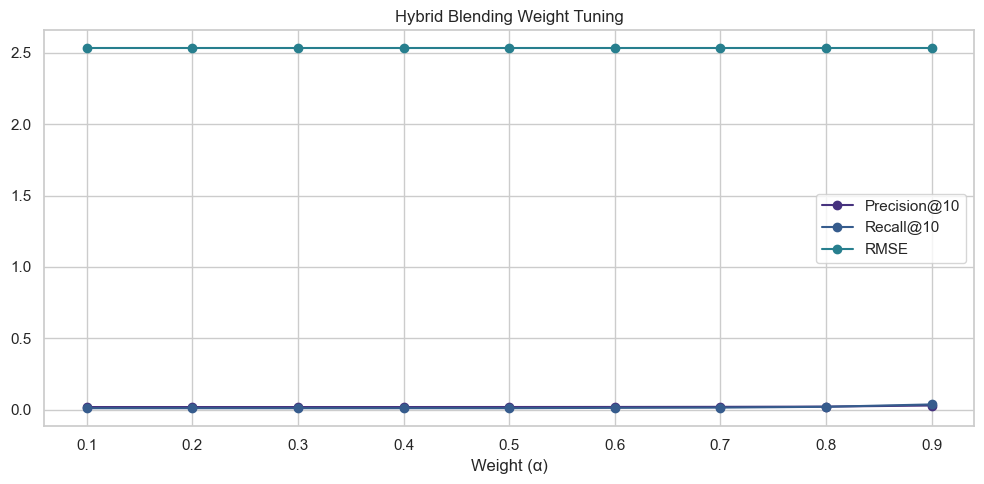

,weight,precision@10,recall@10,rmse
0,0.1,0.017962,0.009981,2.530629
1,0.2,0.017962,0.009981,2.530629
2,0.3,0.017962,0.009981,2.530629
3,0.4,0.017962,0.009981,2.530629
4,0.5,0.018217,0.010022,2.530629
5,0.6,0.018599,0.012116,2.530629
6,0.7,0.019363,0.014039,2.530629
7,0.8,0.021146,0.019644,2.530629
8,0.9,0.028662,0.036385,2.530629


In [13]:
# Generate alpha values from 0.1 to 0.9 in steps of 0.1
alpha_range = [round(w, 1) for w in np.arange(0.1, 1.0, 0.1)]

# Tune hybrid recommender weights using SVDHybridRecommender across alpha_range
tune_hybrid_weights(
    weights=alpha_range, # List of alpha weights to test
    model_class=SVDHybridRecommender, # Hybrid recommender model class
    train_matrix=train_matrix,# Training interaction matrix
    content_sim=content_similarity, # Content-based similarity matrix
    test_matrix=test_matrix, # Test interaction matrix
    precision_k=10, # Precision@10 evaluation metric
    output_path="../data/cleaned/hybrid_tuning_results.csv", # Save results to CSV
    user_map=user_map, # Mapping of user IDs
    item_map=item_map, # Mapping of item IDs
    reverse_item_map=reverse_item_map # Reverse mapping for item IDs
)

In [14]:
# Calculate RMSE on test data
def calculate_rmse(model, test_matrix):
    """
    Calculate Root Mean Squared Error for a model on the given test data.
    
    Parameters:
    model : Trained recommendation model with a predict_rating(user, item) method
    test_matrix : 2D NumPy array or sparse matrix with test ratings

    Returns:
    float : RMSE value
    """
    non_zero_indices = np.where(test_matrix > 0)
    y_true = []
    y_pred = []

    for u, i in zip(non_zero_indices[0], non_zero_indices[1]):
        y_true.append(test_matrix[u, i])
        y_pred.append(model.predict_rating(u, i))

    return np.sqrt(mean_squared_error(y_true, y_pred))

def calculate_precision_recall_at_k(model, test_matrix, train_matrix, k=10):
    """
    Compute average precision@k and recall@k for all users in test set.

    Parameters:
    model : Trained recommendation model with get_recommendations(user, n, exclude_seen, known_items)
    test_matrix : 2D NumPy array with ground truth test interactions
    train_matrix : 2D NumPy array with training interactions
    k : int : Number of top recommendations

    Returns:
    Tuple[float, float] : (Average precision@k, Average recall@k)
    """
    precision_sum = 0.0
    recall_sum = 0.0
    user_count = 0

    for u in range(test_matrix.shape[0]):
        test_items = np.where(test_matrix[u] > 0)[0]
        if len(test_items) == 0:
            continue

        known_items = np.where(train_matrix[u] > 0)[0].tolist()
        recs = model.get_recommendations(u, n=k, exclude_seen=True, known_items=known_items)
        if not recs:
            continue

        rec_items = [item for item, _ in recs]
        hits = len(set(rec_items) & set(test_items))

        precision_sum += hits / min(k, len(rec_items))
        recall_sum += hits / len(test_items)
        user_count += 1

    avg_precision = precision_sum / user_count if user_count > 0 else 0.0
    avg_recall = recall_sum / user_count if user_count > 0 else 0.0
    return avg_precision, avg_recall

# Evaluate the model
rmse = calculate_rmse(svd_recommender, test_matrix)
print(f"RMSE: {rmse:.4f}")

print("Calculating precision@10 and recall@10...")
precision, recall = calculate_precision_recall_at_k(svd_recommender, test_matrix, train_matrix, k=10)
print(f"Precision@10: {precision:.4f}")
print(f"Recall@10: {recall:.4f}")

INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3


RMSE: 2.5306
Calculating precision@10 and recall@10...


INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10 recommendations for user 6
INFO:src.recommender.hybrid:Generated 10 recommendations for user 7
INFO:src.recommender.hybrid:Generated 10 recommendations for user 8
INFO:src.recommender.hybrid:Generated 10 recommendations for user 9
INFO:src.recommender.hybrid:Generated 10 recommendations for user 10
INFO:src.recommender.hybrid:Generated 10 recommendations for user 11
INFO:src.recommender.hybrid:Generated 10 recommendations for user 12
INFO:src.recommender.hybrid:Generated 10 recommendations for user 13
INFO:src.recommender.hybrid:Generated 10 recommendations for user 14
INFO:src.recommender.hybrid:Generated 10 recommendations for user 15
INFO:src.recommender.hybrid:Generated 10 recommendations for user 16
INFO:src.recommender.hybrid:Generated 10 recommendations for user 17
INFO:src.recommender.hybrid:Generated 10

Precision@10: 0.0194
Recall@10: 0.0140


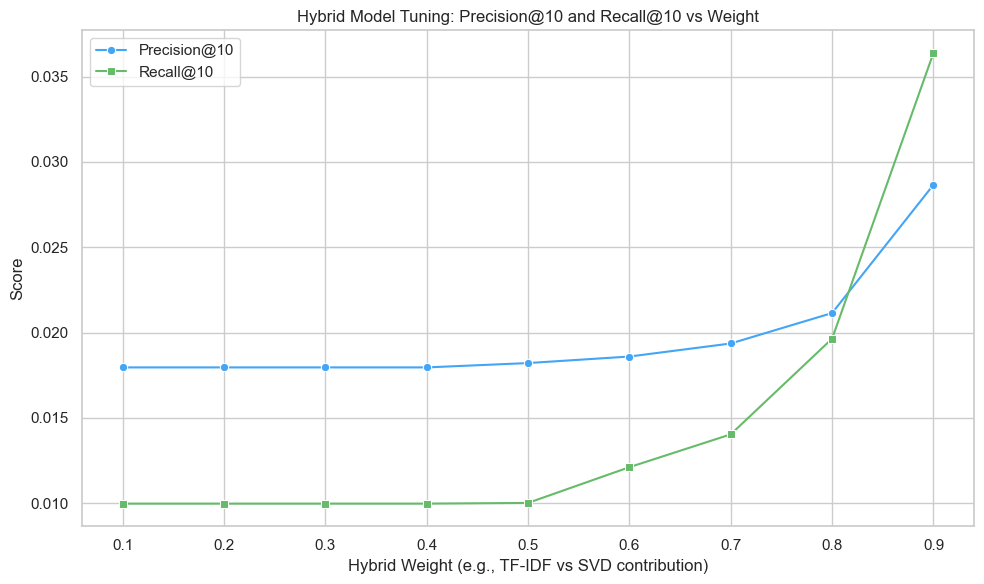

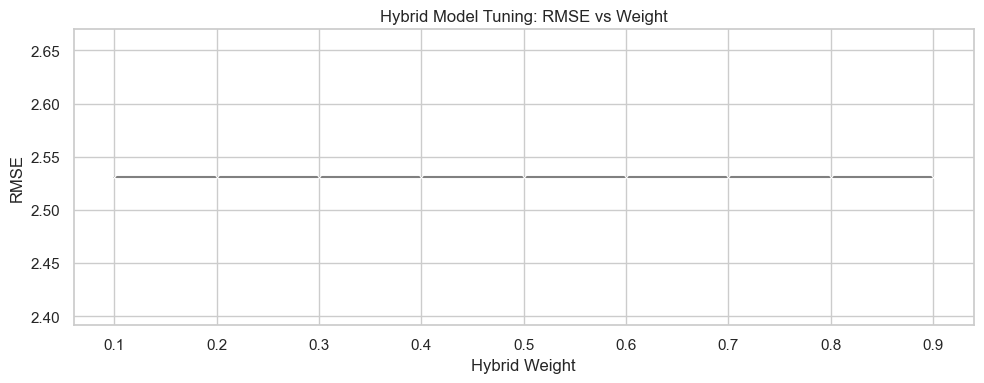

In [15]:
# Step 1: Load data
df = pd.read_csv('../data/cleaned/hybrid_tuning_results.csv')

# Step 2: Plot Precision@10 and Recall@10
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='weight', y='precision@10', marker='o', label='Precision@10', color='#42a5f5')
sns.lineplot(data=df, x='weight', y='recall@10', marker='s', label='Recall@10', color='#66bb6a')

plt.title('Hybrid Model Tuning: Precision@10 and Recall@10 vs Weight')
plt.xlabel('Hybrid Weight (e.g., TF-IDF vs SVD contribution)')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

# Step 3: Plot RMSE separately
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='weight', y='rmse', marker='x', color='gray')

plt.title('Hybrid Model Tuning: RMSE vs Weight')
plt.xlabel('Hybrid Weight')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

## 9. Generate Sample Recommendations

In [16]:
print(list(user_map.keys())[:5])  # See a few valid user IDs

['u100200', 'u100767', 'u101324', 'u101372', 'u102298']


In [17]:
# Generate recommendations for a user
def get_recommendations_for_user(user_id, model, n=10):
    """Generate recommendations for a user."""
    # Get user index
    if user_id not in user_map:
        return []
    
    user_idx = user_map[user_id]
    
    # Get known items
    known_items = np.where(train_matrix[user_idx] > 0)[0]
    
    # Generate recommendations
    recs = model.get_recommendations(user_idx, n=n, exclude_seen=True, known_items=known_items)
    
    # Convert to original IDs
    recommendations = [(reverse_item_map[item], score) for item, score in recs]
    
    return recommendations

# Get recommendations for a sample user
sample_user_id = "u100200"
recommendations = get_recommendations_for_user(sample_user_id, svd_recommender, n=10)

print(f"Recommendations for user {sample_user_id}:")
for i, (bundle_id, score) in enumerate(recommendations, 1):
    print(f"{i}. {bundle_id} (Score: {score:.2f})")

INFO:src.recommender.hybrid:Generated 10 recommendations for user 0


Recommendations for user u100200:
1. b5 (Score: 0.24)
2. b5567 (Score: 0.24)
3. b5579 (Score: 0.24)
4. b160 (Score: 0.24)
5. b192 (Score: 0.24)
6. b5584 (Score: 0.24)
7. b89 (Score: 0.24)
8. b190 (Score: 0.24)
9. b173 (Score: 0.24)
10. b5577 (Score: 0.24)


## 10. Compare with Pure SVD (No Content Features)

In [18]:
# Train a pure SVD model (without content features)
pure_svd = SVDHybridRecommender(n_factors=20, combine_weight=1.0)  # Weight of 1.0 means 100% CF
pure_svd.initialize(train_matrix, user_map, item_map, reverse_item_map)
pure_svd.fit(train_matrix)

# Evaluate pure SVD
pure_rmse = calculate_rmse(pure_svd, test_matrix)
print(f"Pure SVD RMSE: {pure_rmse:.4f}")

print("Calculating precision@10 and recall@10...")
pure_precision, pure_recall = calculate_precision_recall_at_k(pure_svd, test_matrix, train_matrix, k=10)
print(f"Pure SVD Precision@10: {pure_precision:.4f}")
print(f"Pure SVD Recall@10: {pure_recall:.4f}")

# Print comparison
print("\nComparison:")
print("Method      | RMSE    | Precision@10 | Recall@10")
print("------------|---------|--------------|----------")
print(f"Hybrid SVD  | {rmse:.4f}  | {precision:.4f}       | {recall:.4f}")
print(f"Pure SVD    | {pure_rmse:.4f}  | {pure_precision:.4f}       | {pure_recall:.4f}")
print(f"Improvement | {pure_rmse-rmse:.4f}  | {precision-pure_precision:.4f}       | {recall-pure_recall:.4f}")

C:\Users\karat\AppData\Local\Temp\ipykernel_3036\1959226116.py:4: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  pure_svd.fit(train_matrix)
c:\Users\karat\Downloads\Data-Driven-Personalized-Educational-Content-Recommendation-System\.venv\lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
INFO:src.recommender.hybrid:SVD model trained successfully with 20 factors
INFO:src.recommender.hybrid:User factors shape: (881, 20)
INFO:src.recommender.hybrid:Item factors shape: (8256, 20)
INFO:src.recommender.hybrid:Generated 10 recommendations for user 2
INFO:src.recommender.hybrid:Generated 10 recommendations for user 3
INFO:src.recommender.hybrid:Generated 10 recommendations for user 4
INFO:src.recommender.hybrid:Generated 10 recommendations for user 5
INFO:src.recommender.hybrid:Generated 10

Pure SVD RMSE: 2.5306
Calculating precision@10 and recall@10...


INFO:src.recommender.hybrid:Generated 10 recommendations for user 121
INFO:src.recommender.hybrid:Generated 10 recommendations for user 122
INFO:src.recommender.hybrid:Generated 10 recommendations for user 124
INFO:src.recommender.hybrid:Generated 10 recommendations for user 125
INFO:src.recommender.hybrid:Generated 10 recommendations for user 126
INFO:src.recommender.hybrid:Generated 10 recommendations for user 127
INFO:src.recommender.hybrid:Generated 10 recommendations for user 128
INFO:src.recommender.hybrid:Generated 10 recommendations for user 129
INFO:src.recommender.hybrid:Generated 10 recommendations for user 130
INFO:src.recommender.hybrid:Generated 10 recommendations for user 131
INFO:src.recommender.hybrid:Generated 10 recommendations for user 132
INFO:src.recommender.hybrid:Generated 10 recommendations for user 133
INFO:src.recommender.hybrid:Generated 10 recommendations for user 134
INFO:src.recommender.hybrid:Generated 10 recommendations for user 135
INFO:src.recommender

Pure SVD Precision@10: 0.0439
Pure SVD Recall@10: 0.0735

Comparison:
Method      | RMSE    | Precision@10 | Recall@10
------------|---------|--------------|----------
Hybrid SVD  | 2.5306  | 0.0194       | 0.0140
Pure SVD    | 2.5306  | 0.0439       | 0.0735
Improvement | 0.0000  | -0.0246       | -0.0594


## 11. Save the model

In [19]:
# Create directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Create a model package with all necessary components
model_package = {
    'recommender': svd_recommender,
    'user_map': user_map,
    'item_map': item_map,
    'reverse_user_map': reverse_user_map,
    'reverse_item_map': reverse_item_map,
    'metrics': {
        'rmse': rmse,
        'precision@10': precision,
        'recall@10': recall
    }
}

# Save the model
with open("../models/svd_hybrid_model.pkl", "wb") as f:
    pickle.dump(model_package, f)

print("Model saved to ../models/svd_hybrid_model.pkl")

Model saved to ../models/svd_hybrid_model.pkl


In [20]:
# Generate tokenized content features from lecture metadata
def create_content_features(lectures_data):
    features = []
    for _, row in lectures_data.iterrows():
        tokens = []

        # Add part number as a token if available
        if pd.notna(row['part']):
            tokens.append(f"part_{int(row['part'])}")

        # Add numeric tags as tokens (e.g., tag_101)
        if pd.notna(row['tags']):
            tags = str(row['tags']).split(';')
            tokens.extend([f"tag_{t.strip()}" for t in tags if t.strip().isdigit()])

        # Add duration category based on video length
        if pd.notna(row['video_minutes']):
            minutes = row['video_minutes']
            if minutes < 3:
                tokens.append("duration_short")
            elif minutes < 8:
                tokens.append("duration_medium")
            else:
                tokens.append("duration_long")

        # Combine tokens into a single string for each lecture
        features.append(' '.join(tokens))

    return features

def create_content_similarity_matrix(lectures_data, save_path='../models/content_similarity.pkl'):
    """
    Create content-based similarity matrix using TF-IDF
    """
    try:
        # Load existing matrix if available
        if os.path.exists(save_path):
            with open(save_path, 'rb') as f:
                return pickle.load(f)
    except:
        pass
    
    # Create content features
    content_features = create_content_features(lectures_data)
    
    # Create TF-IDF matrix
    tfidf = TfidfVectorizer(
        max_features=1000,
        stop_words='english',
        ngram_range=(1, 2)
    )
    
    tfidf_matrix = tfidf.fit_transform(content_features)
    
    # Calculate cosine similarity
    content_similarity = cosine_similarity(tfidf_matrix)
    
    # Save for future use
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    with open(save_path, 'wb') as f:
        pickle.dump({
            'similarity_matrix': content_similarity,
            'vectorizer': tfidf,
            'features': content_features
        }, f)
    
    return {
        'similarity_matrix': content_similarity,
        'vectorizer': tfidf,
        'features': content_features
    }

# Now create the similarity matrix
similarity_matrix = create_content_similarity_matrix(lectures_data)
print(f"Content similarity matrix shape: {similarity_matrix['similarity_matrix'].shape}")

Content similarity matrix shape: (1021, 1021)


## 12. Test the model

In [21]:
# Check if the model file exists
model_path = "../models/svd_hybrid_model.pkl"
if not os.path.exists(model_path):
    print(f"Model file not found at {model_path}")
else:
    # Load the model package
    with open(model_path, "rb") as f:
        model_package = pickle.load(f)
    
    # Extract components
    svd_recommender = model_package['recommender']
    user_map = model_package['user_map']
    item_map = model_package['item_map']
    reverse_user_map = model_package['reverse_user_map']
    reverse_item_map = model_package['reverse_item_map']
    saved_metrics = model_package['metrics']
    
    # Verify loaded components
    print("Model loaded successfully!")
    print(f"Saved metrics: RMSE={saved_metrics['rmse']:.4f}, Precision@10={saved_metrics['precision@10']:.4f}, Recall@10={saved_metrics['recall@10']:.4f}")
    print(f"User map size: {len(user_map)}")
    print(f"Item map size: {len(item_map)}")

Model loaded successfully!
Saved metrics: RMSE=2.5306, Precision@10=0.0194, Recall@10=0.0140
User map size: 881
Item map size: 8256


In [22]:
# Generate enriched recommendations for a user with metadata details
def get_enriched_recommendations_for_user(user_id, recommender, bundle_info, user_map, reverse_item_map, n=10):
    # Check if user exists in mapping
    if user_id not in user_map:
        print(f"User {user_id} not found in user_map")
        return []

    user_idx = user_map[user_id]

    # Identify items the user has already interacted with
    known_items = np.where(recommender.train_matrix[user_idx] > 0)[0].tolist()

    try:
        # Get top-N recommendations excluding previously seen items
        recs = recommender.get_recommendations(user_idx, n=n, exclude_seen=True, known_items=known_items)
        enriched = []

        for item_idx, score in recs:
            bundle_id = reverse_item_map[item_idx]

            # Retrieve metadata for the recommended bundle
            row = bundle_info[bundle_info['bundle_id'] == bundle_id]
            if row.empty:
                continue

            row = row.iloc[0]

            # Append enriched recommendation with metadata and interaction stats
            enriched.append({
                'bundle_id': bundle_id,
                'score': round(float(score), 4),
                'part': row['part'],
                'tags': row['tags'],
                'question_count': row['question_count'],
                'part_name': row['part_name'],
                'subject_category': row['subject_category'],
                'interaction_count': int(recommender.train_matrix[:, item_idx].sum()),
            })

        return enriched

    except Exception as e:
        # Handle errors gracefully
        print(f"Error generating recommendations: {str(e)}")
        return []

# Sample usage
sample_user_id = list(user_map.keys())[0]
recommendations = get_enriched_recommendations_for_user(
    sample_user_id, svd_recommender, bundle_info, user_map, reverse_item_map, n=10
)

# Organizing the output
if recommendations:
    print(f"\nINFO:src.recommender.hybrid:Generated {len(recommendations)} recommendations for user {sample_user_id}")
    print("="*50)
    print(f"{'Enriched Recommendations for User: u' + str(sample_user_id)}")
    print("="*50)
    print(f"{'Index':<6}{'Bundle ID':<12}{'Part Name':<25}{'Tags':<20}{'Score':<8}{'Subject':<12}{'Questions':<12}{'Interactions':<12}")
    print("-" * 94)
    for i, rec in enumerate(recommendations, 1):
        print(f"{i:<6}{rec['bundle_id']:<12}{rec['part_name']:<25}{rec['tags']:<20}{rec['score']:<8}{rec['subject_category']:<12}{rec['question_count']:<12}{rec['interaction_count']:<12}")
    print("="*50)
else:
    print("No recommendations generated.")

INFO:src.recommender.hybrid:Generated 10 recommendations for user 0



INFO:src.recommender.hybrid:Generated 10 recommendations for user u100200
Enriched Recommendations for User: uu100200
Index Bundle ID   Part Name                Tags                Score   Subject     Questions   Interactions
----------------------------------------------------------------------------------------------
1     b5          Listening Comprehension  8;2;179;181         0.2404  General     1           38          
2     b5567       Listening Comprehension  19;2;184            0.2404  General     1           79          
3     b5579       Listening Comprehension  18;7;183            0.2404  General     1           33          
4     b160        Listening Comprehension  8;2;185             0.2404  General     1           33          
5     b192        Listening Comprehension  3;2;185             0.2404  General     1           21          
6     b5584       Listening Comprehension  11;7;181            0.2404  General     1           34          
7     b89         Listening Co